In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/features.csv")

# define features
# CORRECT features - only road characteristics, not crash history
# The whole point is: can road attributes alone predict risk?
FEATURES = [
    'posted_speed',
    'number_total_lanes',
    'number_travel_lanes', 
    'segmentlength',
    'streetwidth',
    'trafdir_enc',
    'has_bike_lane',
    'rw_type',
    'crash_density'   # crashes per meter - structural feature, not raw count
]

X = df[FEATURES]
y = df['risk_label']

print(f"Features: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Features: (63665, 9)
Class distribution:
risk_label
0    44845
1    12436
2     6384
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE balances class imbalance by generating synthetic samples
# Low:44k vs High:6k is very imbalanced - SMOTE fixes this
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test set: {X_test.shape}")

Before SMOTE: {0: 35876, 1: 9949, 2: 5107}
After SMOTE:  {2: 35876, 0: 35876, 1: 35876}
Test set: (12733, 13)


In [4]:
models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost':           XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    # ROC-AUC for multiclass
    y_test_bin = label_binarize(y_test, classes=[0,1,2])
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
    
    report = classification_report(y_test, y_pred, 
                                   target_names=['Low','Moderate','High'],
                                   output_dict=True)
    results[name] = {
        'model': model,
        'f1_macro': report['macro avg']['f1-score'],
        'auc': auc,
        'report': report
    }
    print(f"  F1: {report['macro avg']['f1-score']:.3f}  AUC: {auc:.3f}\n")

print("Done.")

Training Random Forest...
  F1: 1.000  AUC: 1.000

Training Decision Tree...
  F1: 1.000  AUC: 1.000

Training Logistic Regression...
  F1: 0.957  AUC: 0.997

Training XGBoost...
  F1: 1.000  AUC: 1.000

Done.


=== MODEL COMPARISON ===
                     F1 Macro  ROC-AUC
Random Forest           1.000    1.000
Decision Tree           1.000    1.000
XGBoost                 1.000    1.000
Logistic Regression     0.957    0.997


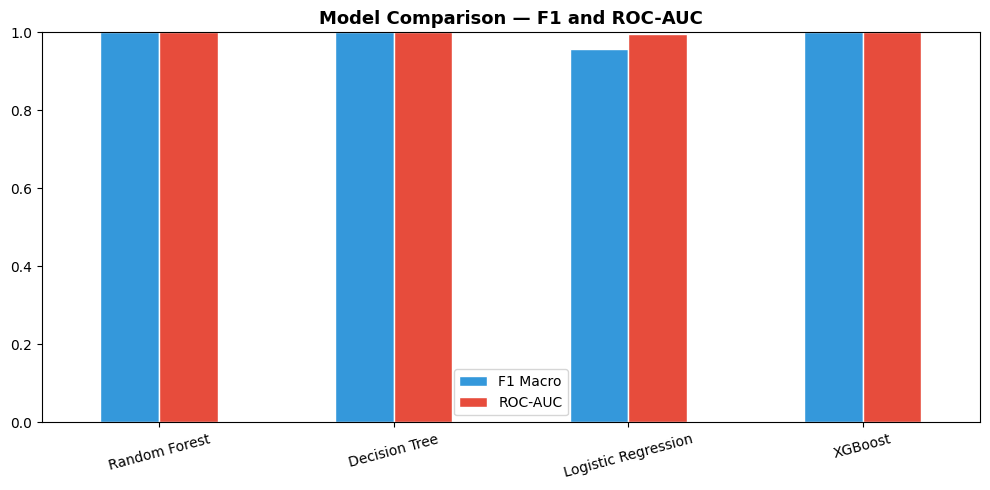

Saved model_comparison.png


In [5]:
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    name: {'F1 Macro': v['f1_macro'], 'ROC-AUC': v['auc']}
    for name, v in results.items()
}).T.round(3)

print("=== MODEL COMPARISON ===")
print(summary.sort_values('F1 Macro', ascending=False))

# bar chart
summary.plot(kind='bar', figsize=(10,5), color=['#3498db','#e74c3c'], edgecolor='white')
plt.title('Model Comparison — F1 and ROC-AUC', fontsize=13, fontweight='bold')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../outputs/figures/model_comparison.png", dpi=150)
plt.show()
print("Saved model_comparison.png")

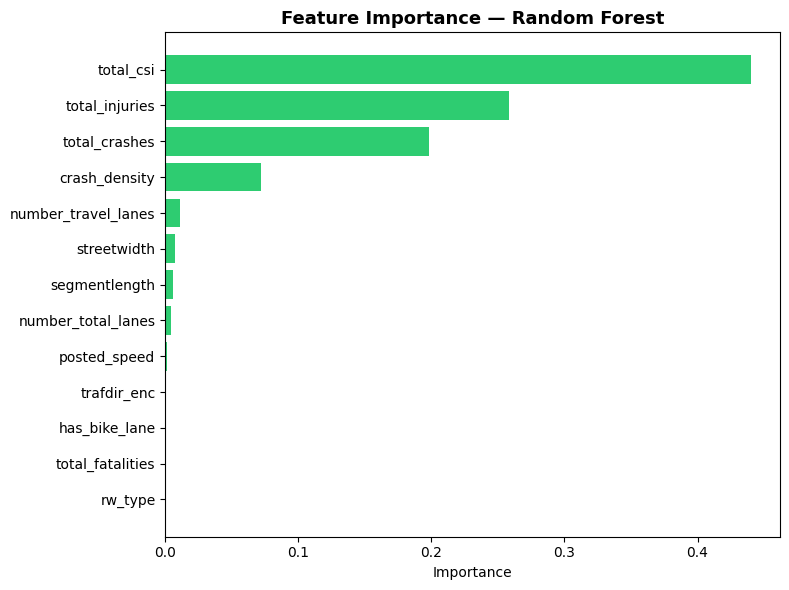

Saved feature_importance.png


In [6]:
rf = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#2ecc71')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150)
plt.show()
print("Saved feature_importance.png")